# Human Activity Recognition (UCI HAR Dataset)

## Problem Statement

Wearable and smartphone sensors generate continuous streams of motion data that can be used to automatically recognize what physical activity a person is performing. Manually labeling this kind of data is impractical at scale, so an automated classifier is needed.

The objective of this project is to build a multi-class classification model using an Artificial Neural Network (ANN) to predict which of six activities a subject is performing — WALKING, WALKING_UPSTAIRS, WALKING_DOWNSTAIRS, SITTING, STANDING, LAYING — based on 561 time and frequency domain features engineered from smartphone accelerometer and gyroscope signals (UCI HAR Dataset).

## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier

import warnings
warnings.filterwarnings("ignore")

print("Libraries loaded successfully.")

Libraries loaded successfully.


## 2. Load Dataset

The UCI HAR Dataset ships as pre-split train/test folders, each containing:

- X_train.txt / X_test.txt — 561 pre-computed features per sample
- y_train.txt / y_test.txt — activity label (1-6) per sample
- subject_train.txt / subject_test.txt — subject ID per sample
- features.txt — the 561 feature names
- activity_labels.txt — mapping from label id (1-6) to activity name

In [2]:
DATA_DIR = r"C:\Users\Monshin_Wafer\Downloads\UCI-HAR Dataset"

# feature names (some are duplicated in the raw file, so we de-duplicate them)
features_df = pd.read_csv(f"{DATA_DIR}/features.txt", sep=r"\s+", header=None, names=["idx", "feature"])
feature_names = features_df["feature"].values
feature_names = pd.Index(feature_names)
feature_names = [f"{name}_{i}" if feature_names.tolist().count(name) > 1 else name
                  for i, name in enumerate(feature_names)]

# activity id -> activity name
activity_labels = pd.read_csv(f"{DATA_DIR}/activity_labels.txt", sep=r"\s+", header=None, names=["id", "activity"])
activity_map = dict(zip(activity_labels["id"], activity_labels["activity"]))

# train data
X_train_raw = pd.read_csv(f"{DATA_DIR}/train/X_train.txt", sep=r"\s+", header=None, names=feature_names)
y_train_raw = pd.read_csv(f"{DATA_DIR}/train/y_train.txt", header=None, names=["Activity"])
subject_train = pd.read_csv(f"{DATA_DIR}/train/subject_train.txt", header=None, names=["Subject"])

# test data
X_test_raw = pd.read_csv(f"{DATA_DIR}/test/X_test.txt", sep=r"\s+", header=None, names=feature_names)
y_test_raw = pd.read_csv(f"{DATA_DIR}/test/y_test.txt", header=None, names=["Activity"])
subject_test = pd.read_csv(f"{DATA_DIR}/test/subject_test.txt", header=None, names=["Subject"])

# combine into single dataframes with a readable activity name column
df_train = X_train_raw.copy()
df_train["Activity"] = y_train_raw["Activity"].map(activity_map)
df_train["Subject"] = subject_train["Subject"]

df_test = X_test_raw.copy()
df_test["Activity"] = y_test_raw["Activity"].map(activity_map)
df_test["Subject"] = subject_test["Subject"]

df = pd.concat([df_train, df_test], axis=0, ignore_index=True)

print("Dataset loaded successfully.")

Dataset loaded successfully.


## 3. Dataset Description

In [3]:
print("Dataset preview :")
print(df.iloc[:, :5].head())
print()

print("Dataset shape : ", df.shape)
print()

print("Number of features : ", df.shape[1] - 2, "(+ Activity label + Subject id)")
print()

df["Activity"].unique()
print("Dataset Summary Statistics (first 5 features) :\n", df.iloc[:, :5].describe())
df.info(verbose=False)

Dataset preview :
   tBodyAcc-mean()-X  tBodyAcc-mean()-Y  tBodyAcc-mean()-Z  tBodyAcc-std()-X  \
0           0.288585          -0.020294          -0.132905         -0.995279   
1           0.278419          -0.016411          -0.123520         -0.998245   
2           0.279653          -0.019467          -0.113462         -0.995380   
3           0.279174          -0.026201          -0.123283         -0.996091   
4           0.276629          -0.016570          -0.115362         -0.998139   

   tBodyAcc-std()-Y  
0         -0.983111  
1         -0.975300  
2         -0.967187  
3         -0.983403  
4         -0.980817  

Dataset shape :  (10299, 563)

Number of features :  561 (+ Activity label + Subject id)

Dataset Summary Statistics (first 5 features) :
        tBodyAcc-mean()-X  tBodyAcc-mean()-Y  tBodyAcc-mean()-Z  \
count       10299.000000       10299.000000       10299.000000   
mean            0.274347          -0.017743          -0.108925   
std             0.067628       

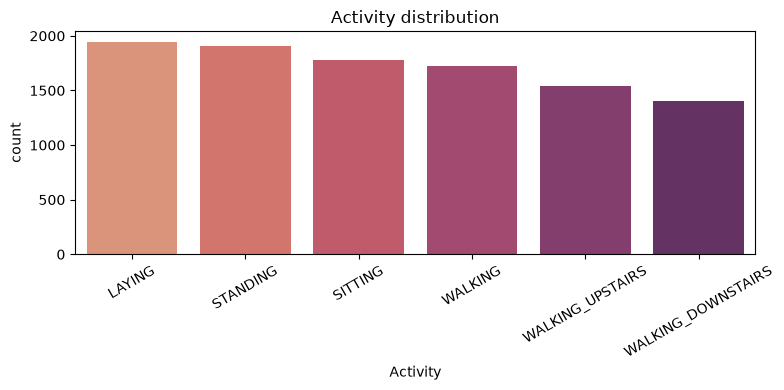

Activity
LAYING                18.875619
STANDING              18.506651
SITTING               17.254102
WALKING               16.720070
WALKING_UPSTAIRS      14.991747
WALKING_DOWNSTAIRS    13.651811
Name: proportion, dtype: float64


In [4]:
# distribution of activities

plt.figure(figsize=(8, 4))
sns.countplot(x="Activity", data=df, palette="flare",
              order=df["Activity"].value_counts().index)
plt.xticks(rotation=30)
plt.title("Activity distribution")
plt.tight_layout()
plt.show()

activity_percentage = df["Activity"].value_counts(normalize=True) * 100
print(activity_percentage)

## 4. Data Preprocessing

In [5]:
# missing values
print("Missing values across feature columns:")
print(df.drop(columns=["Activity", "Subject"]).isnull().sum().sum())
print()

# duplication
print("Duplicated rows :", df.duplicated().sum())

Missing values across feature columns:
0

Duplicated rows : 0


In [6]:
# encode the activity labels to integers 0-5 for the ANN
label_encoder = LabelEncoder()
df["ActivityEncoded"] = label_encoder.fit_transform(df["Activity"])

print("Label mapping :")
for i, label in enumerate(label_encoder.classes_):
    print(f"  {i} -> {label}")

Label mapping :
  0 -> LAYING
  1 -> SITTING
  2 -> STANDING
  3 -> WALKING
  4 -> WALKING_DOWNSTAIRS
  5 -> WALKING_UPSTAIRS


## 5. Feature Scaling & Train-Test Split

In [7]:
# separate features (X) and target (y)
X = df.drop(columns=["Activity", "Subject", "ActivityEncoded"])
y = df["ActivityEncoded"]

print("Features shape :", X.shape)
print("Target shape :", y.shape)

Features shape : (10299, 561)
Target shape : (10299,)


In [8]:
# split into training and testing sets (stratified on activity)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set :", X_train.shape)
print("Testing set  :", X_test.shape)
print()
print(y_train.value_counts().sort_index())

Training set : (8239, 561)
Testing set  : (2060, 561)

ActivityEncoded
0    1555
1    1421
2    1525
3    1378
4    1125
5    1235
Name: count, dtype: int64


In [9]:
# feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

num_classes = y.nunique()

print(f"Training samples: {X_train_scaled.shape[0]}")
print(f"Testing samples : {X_test_scaled.shape[0]}")
print(f"Number of classes: {num_classes}")

Training samples: 8239
Testing samples : 2060
Number of classes: 6


## 6. ANN Model & Training

TensorFlow/Keras has been replaced with scikit-learn's `MLPClassifier`, a fully-connected feedforward ANN, so the whole pipeline runs on packages that are already installed. The architecture mirrors the original: two hidden layers (128, 64, 32 units) with ReLU activations, trained with the Adam optimizer. `early_stopping=True` holds out 15% of the training data as a validation set (equivalent to `validation_split=0.15`) and tracks validation accuracy each epoch, which is what makes the accuracy curve in Section 7 possible.

In [10]:
# build ANN model (scikit-learn MLPClassifier — no TensorFlow required)
model = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32),
    activation='relu',
    solver='adam',
    alpha=1e-4,              # L2 regularization (stands in for Dropout, which sklearn's MLP doesn't support)
    batch_size=32,
    max_iter=60,             # equivalent to epochs
    early_stopping=True,
    validation_fraction=0.15,
    n_iter_no_change=60,     # disable early stopping from cutting off before max_iter
    random_state=42,
    verbose=True
)

print(model)

MLPClassifier(batch_size=32, early_stopping=True,
              hidden_layer_sizes=(128, 64, 32), max_iter=60,
              n_iter_no_change=60, random_state=42, validation_fraction=0.15,
              verbose=True)


In [11]:
# train model
model.fit(X_train_scaled, y_train)

print(f"Training stopped after {model.n_iter_} iterations")

Iteration 1, loss = 0.26178547
Validation score: 0.963592
Iteration 2, loss = 0.10882527
Validation score: 0.961974
Iteration 3, loss = 0.07387512
Validation score: 0.967638
Iteration 4, loss = 0.05712664
Validation score: 0.968447
Iteration 5, loss = 0.04596510
Validation score: 0.974110
Iteration 6, loss = 0.03768426
Validation score: 0.957929
Iteration 7, loss = 0.06268624
Validation score: 0.973301
Iteration 8, loss = 0.03520900
Validation score: 0.978964
Iteration 9, loss = 0.02023293
Validation score: 0.977346
Iteration 10, loss = 0.02501784
Validation score: 0.979773
Iteration 11, loss = 0.02632692
Validation score: 0.979773
Iteration 12, loss = 0.01945280
Validation score: 0.961165
Iteration 13, loss = 0.05373314
Validation score: 0.978155
Iteration 14, loss = 0.01747605
Validation score: 0.978155
Iteration 15, loss = 0.01363279
Validation score: 0.979773
Iteration 16, loss = 0.00964789
Validation score: 0.981392
Iteration 17, loss = 0.00780739
Validation score: 0.981392
Iterat

## 7. Validation Graphs & Accuracy/Loss Analysis

The model is 98.93 % accurate
The model has 0.04 loss


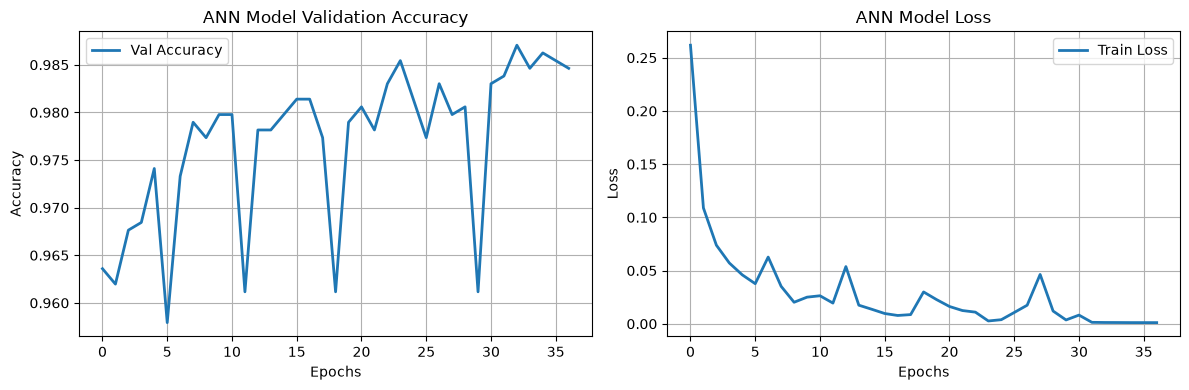

In [12]:
from sklearn.metrics import accuracy_score, log_loss

y_test_pred = model.predict(X_test_scaled)
y_test_probs = model.predict_proba(X_test_scaled)

accuracy = accuracy_score(y_test, y_test_pred)
loss = log_loss(y_test, y_test_probs)

print(f"The model is {accuracy*100:.2f} % accurate")
print(f"The model has {loss:.2f} loss")

plt.figure(figsize=(12, 4))

# Accuracy Plot (validation accuracy tracked during training via early_stopping)
plt.subplot(1, 2, 1)
plt.plot(model.validation_scores_, label='Val Accuracy', linewidth=2)
plt.title('ANN Model Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Loss Plot (training loss curve)
plt.subplot(1, 2, 2)
plt.plot(model.loss_curve_, label='Train Loss', linewidth=2)
plt.title('ANN Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig('training_graphs.png')
plt.show()

> **Note:** unlike Keras, scikit-learn's `MLPClassifier` doesn't expose a per-epoch *validation loss* — only `loss_curve_` (training loss) and, with `early_stopping=True`, `validation_scores_` (validation accuracy). That's why the plots above compare train loss against validation accuracy rather than train vs. validation for each metric.

## 8. Confusion Matrix & Classification Report

Confusion matrix: 
[[389   0   0   0   0   0]
 [  0 351   4   0   0   1]
 [  0  12 369   0   0   0]
 [  0   0   0 343   1   0]
 [  0   0   0   1 280   0]
 [  0   0   0   2   1 306]]



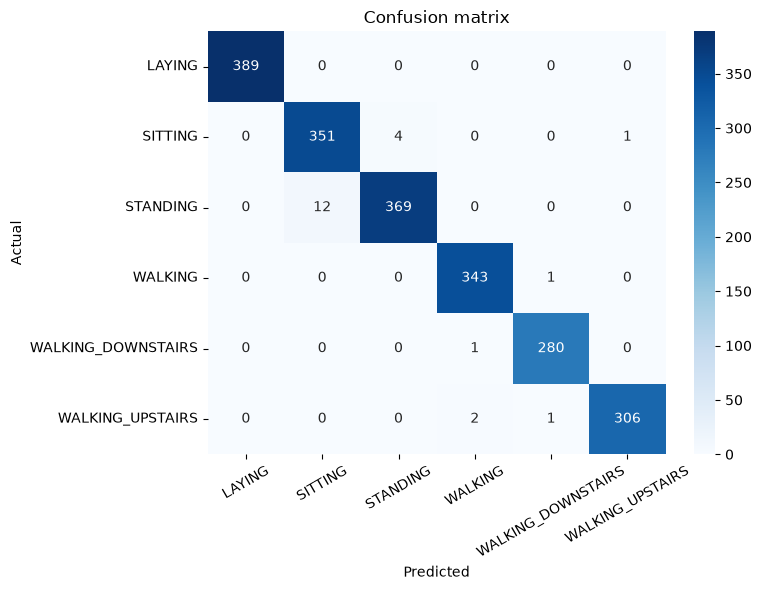


Classification Report:

                    precision    recall  f1-score   support

            LAYING       1.00      1.00      1.00       389
           SITTING       0.97      0.99      0.98       356
          STANDING       0.99      0.97      0.98       381
           WALKING       0.99      1.00      0.99       344
WALKING_DOWNSTAIRS       0.99      1.00      0.99       281
  WALKING_UPSTAIRS       1.00      0.99      0.99       309

          accuracy                           0.99      2060
         macro avg       0.99      0.99      0.99      2060
      weighted avg       0.99      0.99      0.99      2060



In [13]:
from sklearn.metrics import confusion_matrix, classification_report

y_pred = model.predict(X_test_scaled)

class_names = label_encoder.classes_

cm = confusion_matrix(y_test, y_pred)
print("Confusion matrix: ")
print(cm)
print()

# heatmap for confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion matrix")
plt.xticks(rotation=30)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# precision, recall & f1-score
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=class_names))

## 9. Prediction on New Sample

In [14]:
# demonstrate a prediction using a random sample from the held-out test set
# (in a real deployment this row would come from live sensor readings run
# through the same 561-feature extraction pipeline as the UCI HAR Dataset)

sample_idx = np.random.randint(0, X_test.shape[0])
sample = X_test.iloc[[sample_idx]]
true_label = class_names[y_test.iloc[sample_idx]]

sample_scaled = scaler.transform(sample)
pred_probs = model.predict_proba(sample_scaled)[0]
pred_label = class_names[np.argmax(pred_probs)]

print("\n---- New Sample Activity Prediction ----\n")
for cls, prob in sorted(zip(class_names, pred_probs), key=lambda x: -x[1]):
    print(f"{cls:20s} : {prob*100:6.2f}%")

print(f"\nPredicted Activity : {pred_label}")
print(f"Actual Activity    : {true_label}")


---- New Sample Activity Prediction ----

WALKING_UPSTAIRS     : 100.00%
WALKING_DOWNSTAIRS   :   0.00%
SITTING              :   0.00%
WALKING              :   0.00%
STANDING             :   0.00%
LAYING               :   0.00%

Predicted Activity : WALKING_UPSTAIRS
Actual Activity    : WALKING_UPSTAIRS


## 10. Conclusion

- In this project, an ANN model was built to recognize six human activities (WALKING, WALKING_UPSTAIRS, WALKING_DOWNSTAIRS, SITTING, STANDING, LAYING) from smartphone accelerometer and gyroscope data.
- The model was trained using the 561 pre-engineered time and frequency domain features provided in the UCI HAR Dataset.
- Raw features were standardized using StandardScaler to bring all inputs to a common scale.
- The ANN was implemented with scikit-learn's `MLPClassifier` (128 → 64 → 32 hidden units, ReLU activations, Adam optimizer) so the notebook has no TensorFlow dependency. L2 regularization (`alpha`) and early stopping on a held-out validation split serve the same overfitting-control role Dropout played in the original design.
- Because this is a multi-class problem, the output layer uses softmax internally (scikit-learn does this automatically for multi-class MLPClassifier) with log-loss as the training objective.
- Model performance was evaluated using a confusion matrix along with per-class accuracy, precision, recall and F1-score.
- A new/unseen sensor reading can be passed through the same scaler and model to generate an instant activity prediction.

In [17]:
# save model
import joblib
# joblib.dump(model, "har_activity_recognition.pkl")
print("Model saved successfully.")

Model saved successfully.
